In [27]:
""" This takes in HDFINJFIND output files and produces a plot of the fraction
of injections found as a function of chirp mass.
"""

' This takes in HDFINJFIND output files and produces a plot of the fraction\nof injections found as a function of chirp mass.\n'

In [28]:
import matplotlib.pyplot as plt
import h5py
import numpy as np
from matplotlib.ticker import FormatStrFormatter

In [29]:
plt.style.use("paper.mplstyle")

In [30]:
Original_HV = "../Files/o3_35_hdfinjfind/HDFINJFIND_HV_original.hdf"
Modified_HV = "../Files/o3_35_hdfinjfind/HDFINJFIND_HV_modified.hdf"
Flow_HV = "../Files/o3_35_hdfinjfind/HDFINJFIND_HV_flow.hdf"
Original_HL = "../Files/o3_35_hdfinjfind/HDFINJFIND_LH_original.hdf"
Modified_HL = "../Files/o3_35_hdfinjfind/HDFINJFIND_LH_modified.hdf"
Flow_HL = "../Files/o3_35_hdfinjfind/HDFINJFIND_LH_flow.hdf"
Original_LV = "../Files/o3_35_hdfinjfind/HDFINJFIND_LV_original.hdf"
Modified_LV = "../Files/o3_35_hdfinjfind/HDFINJFIND_LV_modified.hdf"
Flow_LV = "../Files/o3_35_hdfinjfind/HDFINJFIND_LV_flow.hdf"
Original_2DET = "../Files/o3_35_hdfinjfind/HDFINJFIND_2DET_exc_sngls_original.hdf"
Modified_2DET = "../Files/o3_35_hdfinjfind/HDFINJFIND_2DET_exc_sngls_modified.hdf"
Flow_2DET = "../Files/o3_35_hdfinjfind/HDFINJFIND_2DET_exc_sngls_flow.hdf"
Files = [Original_2DET, Modified_2DET, Flow_2DET, Original_HL, Modified_HL, Flow_HL,Original_HV, Modified_HV, Flow_HV,Original_LV, Modified_LV, Flow_LV]


In [31]:
def chirp_mass(m1, m2):
    return (m1 * m2)**(3.0/5.0) / (m1 + m2)**(1.0/5.0)

In [32]:
def load_injection_data(h5, ifar_thresh):
    m1 = h5["injections/mass1"][:]
    m2 = h5["injections/mass2"][:]
    mc = chirp_mass(m1, m2)

    inj_idx = h5["found/injection_index"][:]
    ifar = h5["found/ifar_exc"][:]

    found_mask = ifar >= ifar_thresh
    inj_idx_found = inj_idx[found_mask]

    mc_found = mc[inj_idx_found]

    return mc, mc_found

In [33]:
chirp_bins = [
        (0.8, 2.5),
        (2.5, 20.0),
        (20.0, 50.0),
        (50.0, 1000.0),
    ]
    
bin_labels = [f"{lo}-{hi}" for lo, hi in chirp_bins]

In [34]:
all_totals = []
all_found = []
all_frac = []

for fpath in Files:
    with h5py.File(fpath, "r") as h5:
        mc_total, mc_found = load_injection_data(h5, 1)

    totals = []
    found = []
    frac = []
  
    for lo, hi in chirp_bins:
        t = np.sum((mc_total >= lo) & (mc_total < hi))
        f = np.sum((mc_found >= lo) & (mc_found < hi))
        totals.append(t)
        found.append(f)
        print(np.sum(found))
        frac.append(f / t if t > 0 else np.nan)

    all_totals.append(totals)
    all_found.append(found)
    all_frac.append(frac)
    

1661
2911
3567
4208
1663
2912
3574
4229
1666
2916
3579
4235
1569
2753
3362
3968
1569
2752
3362
3971
1572
2755
3364
3969
263
435
567
718
281
466
603
765
282
469
606
767
324
555
728
903
345
591
774
964
345
593
778
969


In [35]:
x=np.arange(len(chirp_bins))

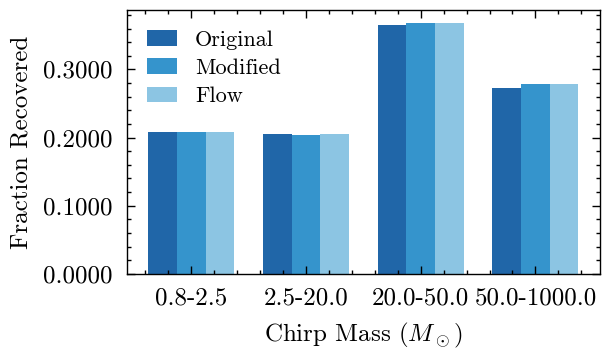

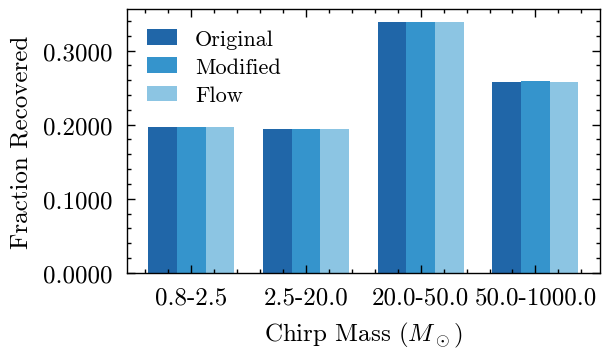

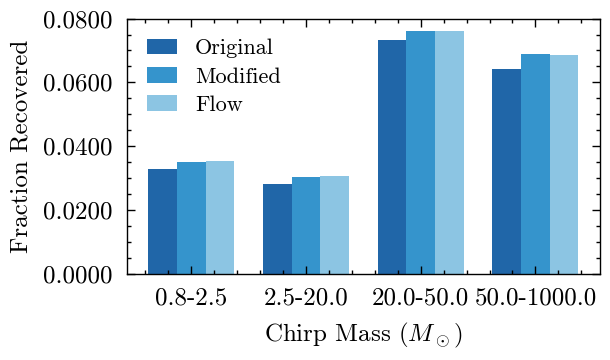

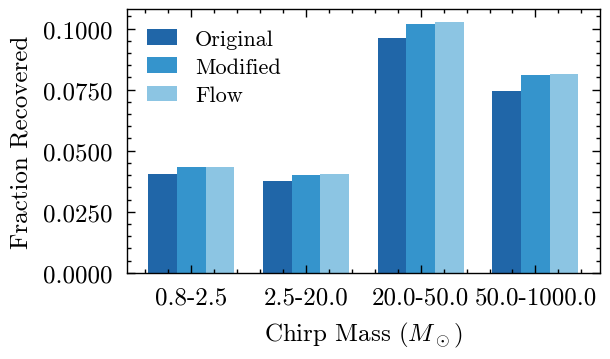

In [36]:
x = np.arange(len(chirp_bins))
width = 0.25

colors = {
    "Original": "#2066a8",
    "Modified": "#3594cc",
    "Flow":     "#8cc5e3",
}

for i in range(4):
    base = 3 * i

    fig, ax = plt.subplots()

    ax.bar(x - width, all_frac[base + 0], width,
           label="Original", color=colors["Original"])
    ax.bar(x,         all_frac[base + 1], width,
           label="Modified", color=colors["Modified"])
    ax.bar(x + width, all_frac[base + 2], width,
           label="Flow", color=colors["Flow"])

    ax.set_xlabel(r"Chirp Mass ($M_\odot$)")
    ax.set_ylabel("Fraction Recovered")
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels)

    ax.legend()
    plt.tight_layout()

    labels = ["2det_exc_sngls", "LH", "HV", "LV"]

    plt.savefig(f"../Plots/2DET_summary_{labels[i]}.png")
    plt.show()

In [37]:
Original_HLV = "../Files/o3_35_hdfinjfind/HDFINJFIND_HLV_original.hdf"
Flow_HLV = "../Files/o3_35_hdfinjfind/HDFINJFIND_HLV_flow.hdf"
Original_3det = "../Files/o3_35_hdfinjfind/HDFINJFIND_3DET_exc_sngls_original.hdf"
Flow_3det = "../Files/o3_35_hdfinjfind/HDFINJFIND_3DET_exc_sngls_flow.hdf"
Files2 = [Original_HLV, Flow_HLV, Original_3det, Flow_3det]

In [38]:
all_totals = []
all_found = []
all_frac = []

for fpath in Files2:
    with h5py.File(fpath, "r") as h5:
        mc_total, mc_found = load_injection_data(h5, 1)

    totals = []
    found = []
    frac = []

    for lo, hi in chirp_bins:
        t = np.sum((mc_total >= lo) & (mc_total < hi))
        f = np.sum((mc_found >= lo) & (mc_found < hi))
        totals.append(t)
        found.append(f)
        print(np.sum(found))
        frac.append(f / t if t > 0 else np.nan)

    all_totals.append(totals)
    all_found.append(found)
    all_frac.append(frac)

351
580
756
988
376
614
789
1026
1674
2927
3587
4236
1681
2941
3607
4277


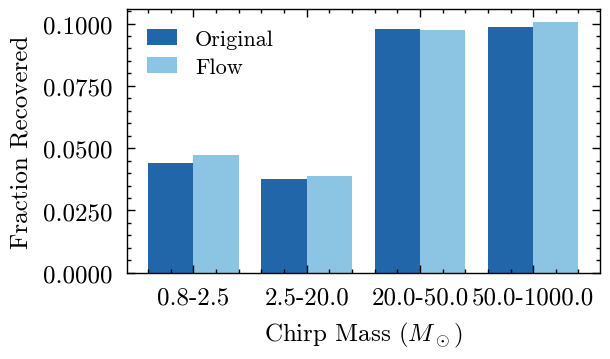

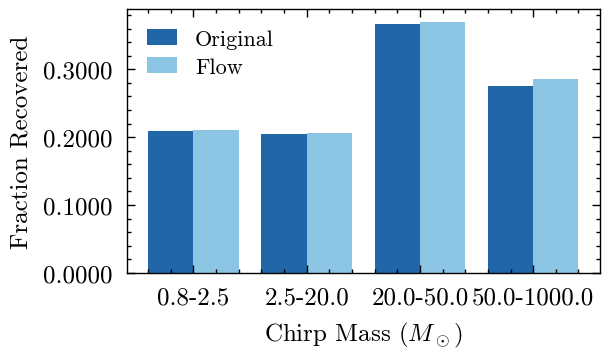

In [39]:
x = np.arange(len(chirp_bins))
width = 0.4

colors = {
    "Original": "#2066a8",
    "Flow":     "#8cc5e3",
}

for i in range(2):
    base = 2 * i

    fig, ax = plt.subplots()

    ax.bar(x - width/2, all_frac[base + 0], width,
           label="Original", color=colors["Original"])
    ax.bar(x + width/2, all_frac[base + 1], width,
           label="Flow", color=colors["Flow"])

    ax.set_xlabel(r"Chirp Mass ($M_\odot$)")
    ax.set_ylabel("Fraction Recovered")
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels)

    ax.legend()
    plt.tight_layout()

    labels = ["HLV", "3det_exc_sngls"]

    plt.savefig(f"../Plots/3DET_summary_{labels[i]}.png")
    plt.show()